# IndoBERTweet Inference — Separate Toxic & Polar Models (Precision-Optimised)
**Purpose:** Load two separately fine-tuned models (hyperparameters tuned on full dataset), tune thresholds optimising for **precision with minimum recall floor (0.30)**, run batch inference on YouTube comments.

**Models:** `indobertweet_toxic_full_finetuned/` and `indobertweet_polar_full_finetuned/`

**Output:** `predictions_precision.csv` and `content_analysis_precision.png`


## 1. Install & Imports

In [1]:
!pip install torch transformers datasets scikit-learn emoji --quiet

import re, os, time
import emoji
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from transformers import BertTokenizer, BertModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, roc_auc_score,
    precision_score, recall_score,
    average_precision_score
)
from datasets import load_dataset

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_LEN = 128
SEED    = 42

print(f'Device: {DEVICE}')


Device: cpu


## 2. Load Toxic & Polar Models
Update `TOXIC_DIR` and `POLAR_DIR` to the paths of your downloaded **full dataset** model folders.

These models were tuned using Optuna on the full 80% training set (30 trials, K=3 StratifiedKFold).

In [2]:
TOXIC_DIR = 'C:\\Users\\cheow\\OneDrive - London School of Economics\\Capstone\\indobertweet_toxic_full_finetuned'
POLAR_DIR = 'C:\\Users\\cheow\\OneDrive - London School of Economics\\Capstone\\indobertweet_polar_full_finetuned'


class IndoBERTweetSingle(nn.Module):
    """Single-task model — one classification head."""
    def __init__(self, save_dir, dropout=0.1):
        super().__init__()
        self.bert      = BertModel.from_pretrained(save_dir)
        self.drop      = nn.Dropout(dropout)
        self.task_head = nn.Linear(768, 1)

    def forward(self, input_ids, attention_mask):
        out    = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.drop(out.pooler_output)
        return self.task_head(pooled).squeeze(-1)


# Load tokenizer (shared — both models use same IndoBERTweet vocab)
tokenizer = BertTokenizer.from_pretrained(TOXIC_DIR)

# Load toxic model
toxic_model = IndoBERTweetSingle(TOXIC_DIR).to(DEVICE)
toxic_head  = torch.load(os.path.join(TOXIC_DIR, 'classification_head.pt'), map_location=DEVICE)
toxic_model.task_head.load_state_dict(toxic_head['toxic_head'])
toxic_model.eval()
print(f'\u2713 Toxic model loaded from: {TOXIC_DIR}')

# Load polar model
polar_model = IndoBERTweetSingle(POLAR_DIR).to(DEVICE)
polar_head  = torch.load(os.path.join(POLAR_DIR, 'classification_head.pt'), map_location=DEVICE)
polar_model.task_head.load_state_dict(polar_head['polar_head'])
polar_model.eval()
print(f'\u2713 Polar model loaded from: {POLAR_DIR}')

# Print best params for each model
for label, d in [('Toxic', TOXIC_DIR), ('Polar', POLAR_DIR)]:
    params = pd.read_csv(os.path.join(d, 'best_params.csv'))
    print(f'\n{label} best Optuna params:')
    print(params.T.to_string())


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✓ Toxic model loaded from: C:\Users\cheow\OneDrive - London School of Economics\Capstone\indobertweet_toxic_full_finetuned


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✓ Polar model loaded from: C:\Users\cheow\OneDrive - London School of Economics\Capstone\indobertweet_polar_full_finetuned

Toxic best Optuna params:
                     0
lr            0.000024
batch_size    8.000000
dropout       0.162407
weight_decay  0.000294
warmup_steps  0.000000

Polar best Optuna params:
                       0
lr              0.000073
batch_size     16.000000
dropout         0.487964
weight_decay    0.031429
warmup_steps  100.000000


## 3. Preprocessing
Extended preprocessing for YouTube comments — same pipeline as training.

In [3]:
# Susanto et. al. (2025) did not mention the text preprocessing steps they employed.
# Hence, the code below follows Koto et. al. (2021) for baseline text preprocessing, with extensions
# to address the structural characteristics of YouTube comments.
# The same preprocessing pipeline is used for both fine-tuning and inference.

def preprocess(text):
    text = str(text).lower()                                                    # IndoBERTweet is an uncased model
    text = re.sub(r'http\S+|www\.\S+', 'HTTPURL', text)                         # URL → learned token
    text = re.sub(r'@\w+', '@USER', text)                                       # mention → learned token
    text = emoji.demojize(text, delimiters=(" ", " "))                          # emoji → text
    text = text.replace("<br>", " ").replace("\n", " ").replace("\t", " ")      # remove formatting artifacts
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)                                  # squash spam
    text = re.sub(r'\s+', ' ', text)                                            # replace all whitespace sequences
    return text.strip()

sample = '@BudiSantoso cek ini https://t.co/abc123 \U0001f621 ANJIRRRR'
print('Before:', sample)
print('After: ', preprocess(sample))


Before: @BudiSantoso cek ini https://t.co/abc123 😡 ANJIRRRR
After:  @USER cek ini HTTPURL enraged_face anjirr


## 4. Threshold Tuning (Precision-Optimised)
Each model is tuned on its own task-specific validation set.

**Objective:** Maximise precision subject to a minimum recall floor of 0.30.

**Rationale:** For a conservative baseline characterisation, false positives (incorrectly classifying neutral comments as harmful) are treated as more costly than false negatives. The recall floor of 0.30 prevents the threshold from becoming so strict that the model classifies almost nothing as positive.

**Note:** Thresholds are derived from IndoDiscourse validation data and serve as a principled lower bound.

In [ ]:
print('Loading IndoDiscourse from HuggingFace...')

def majority_vote(label_list):
    if not label_list: return 0
    return int(sum(int(x) for x in label_list) > len(label_list) / 2)

ds = load_dataset('Exqrch/IndoDiscourse', 'main', split='main')
all_texts, all_toxic, all_polar = [], [], []
for row in ds:
    all_texts.append(row['text'])
    all_toxic.append(majority_vote(row['toxicity']))
    all_polar.append(majority_vote(row['polarized']))
print(f'Loaded {len(all_texts):,} texts')


def get_val_set(texts, labels, task_name):
    """Recreate task-specific validation split matching training setup."""
    rng      = np.random.default_rng(SEED)
    combined = list(zip(texts, labels))
    pos      = [x for x in combined if x[1] == 1]
    neg      = [x for x in combined if x[1] == 0]
    neg_s    = [neg[i] for i in rng.choice(len(neg), min(len(neg), len(pos)*3), replace=False)]
    balanced = list({tuple(x): x for x in pos + neg_s}.values())
    rng.shuffle(balanced)
    t, l = zip(*balanced)
    _, va_t, _, va_l = train_test_split(list(t), list(l), test_size=0.2, random_state=SEED)
    print(f'{task_name} validation: {len(va_t):,} texts | positive: {sum(va_l):,} ({sum(va_l)/len(va_l)*100:.1f}%)')
    return va_t, va_l

va_toxic_texts, va_toxic_labels = get_val_set(all_texts, all_toxic, 'Toxic')
va_polar_texts, va_polar_labels = get_val_set(all_texts, all_polar, 'Polar')


class SingleValDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.texts, self.labels, self.tokenizer = texts, labels, tokenizer
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(preprocess(self.texts[idx]), max_length=MAX_LEN,
                             padding='max_length', truncation=True, return_tensors='pt')
        return {'input_ids': enc['input_ids'].squeeze(),
                'attention_mask': enc['attention_mask'].squeeze(),
                'label': torch.tensor(self.labels[idx], dtype=torch.float)}


def collect_probs(model, texts, labels):
    dl = DataLoader(SingleValDataset(texts, labels, tokenizer), batch_size=32)
    probs, trues = [], []
    with torch.no_grad():
        for batch in dl:
            logit = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE))
            probs.extend(torch.sigmoid(logit).cpu().numpy())
            trues.extend(batch['label'].numpy())
    return np.array(probs), np.array(trues)

print('\nRunning forward passes (~5 min per model on CPU)...')
t_probs, t_true = collect_probs(toxic_model, va_toxic_texts, va_toxic_labels)
print('Toxic done.')
p_probs, p_true = collect_probs(polar_model, va_polar_texts, va_polar_labels)
print('Polar done.')


MIN_RECALL = 0.30  # minimum recall floor

def find_best_threshold(probs, true_labels, task_name):
    """
    Two-pass threshold search optimising for precision
    subject to a minimum recall floor of MIN_RECALL.
    Serves as a principled lower bound on strictness
    derived from IndoDiscourse validation data.
    """
    # Pass 1 — scan all thresholds
    best_t, best_prec = 0.5, 0
    f1_best_t, best_f1 = 0.5, 0  # also track Macro F1 best for comparison
    results = []
    for t in np.arange(0.05, 0.96, 0.01):
        t    = round(t, 2)
        preds = (probs > t).astype(int)
        prec  = precision_score(true_labels, preds, pos_label=1, zero_division=0)
        rec   = recall_score(true_labels, preds, pos_label=1, zero_division=0)
        f1    = f1_score(true_labels, preds, average='macro')
        results.append((t, prec, rec, f1))

        # Precision-optimised: maximise precision with recall >= MIN_RECALL
        if rec >= MIN_RECALL and prec > best_prec:
            best_prec, best_t = prec, t

        # Also track Macro F1 best for comparison
        if f1 > best_f1:
            best_f1, f1_best_t = f1, t

    # Pass 2 — print full table with single marker on selected threshold
    print(f'\n{task_name} threshold search (precision-optimised, MIN_RECALL={MIN_RECALL}):')
    print(f'  {"Threshold":>10} {"Precision":>10} {"Recall":>10} {"Macro F1":>10}')
    print(f'  {"-"*45}')
    for t, prec, rec, f1 in results:
        marker = ' <- selected' if abs(t - best_t) < 0.001 else \
                 ' <- F1 best' if abs(t - f1_best_t) < 0.001 else ''
        print(f'  {t:>10.2f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}{marker}')
    return best_t, best_prec, f1_best_t, best_f1

TOXIC_THRESHOLD, toxic_prec_tuned, toxic_f1_t, toxic_f1_tuned = find_best_threshold(t_probs, t_true, 'Toxic')
POLAR_THRESHOLD, polar_prec_tuned, polar_f1_t, polar_f1_tuned = find_best_threshold(p_probs, p_true, 'Polar')

print(f"\n{'='*55}")
print('SELECTED THRESHOLDS (Precision-Optimised, MIN_RECALL=0.30)')
print(f"{'='*55}")
print(f'Toxic     : {TOXIC_THRESHOLD:.2f}  ->  Precision: {toxic_prec_tuned:.4f}')
print(f'Polarizing: {POLAR_THRESHOLD:.2f}  ->  Precision: {polar_prec_tuned:.4f}')
print(f"\n{'='*55}")
print('COMPARISON: Macro F1 threshold vs Precision-optimised threshold')
print(f"{'='*55}")
print(f"{'':20} {'Toxic(F1)':>10} {'Toxic(Prec)':>12} {'Polar(F1)':>10} {'Polar(Prec)':>12}")
print(f"{'Threshold':20} {toxic_f1_t:>10.2f} {TOXIC_THRESHOLD:>12.2f} {polar_f1_t:>10.2f} {POLAR_THRESHOLD:>12.2f}")
print('-'*65)
for name, fn, kwargs in [
    ('Macro F1',  f1_score,        {'average': 'macro'}),
    ('Precision', precision_score, {'pos_label': 1, 'zero_division': 0}),
    ('Recall',    recall_score,    {'pos_label': 1, 'zero_division': 0}),
]:
    t_f1   = fn(t_true, (t_probs>toxic_f1_t).astype(int), **kwargs)
    t_prec = fn(t_true, (t_probs>TOXIC_THRESHOLD).astype(int), **kwargs)
    p_f1   = fn(p_true, (p_probs>polar_f1_t).astype(int), **kwargs)
    p_prec = fn(p_true, (p_probs>POLAR_THRESHOLD).astype(int), **kwargs)
    print(f'{name:<20} {t_f1:>10.4f} {t_prec:>12.4f} {p_f1:>10.4f} {p_prec:>12.4f}')


# Full evaluation at optimal thresholds
print(f"\n{'='*55}")
print('FULL EVALUATION AT OPTIMAL THRESHOLDS')
print(f"{'='*55}")
for task, probs, true, thresh in [
    ('Toxic',      t_probs, t_true, TOXIC_THRESHOLD),
    ('Polarizing', p_probs, p_true, POLAR_THRESHOLD),
]:
    bin_p = (probs > thresh).astype(int)
    print(f'\n{task}:')
    print(f'  Macro F1   : {f1_score(true, bin_p, average="macro"):.4f}')
    print(f'  ROC AUC    : {roc_auc_score(true, probs):.4f}')
    print(f'  Precision  : {precision_score(true, bin_p, pos_label=1, zero_division=0):.4f}')
    print(f'  Recall     : {recall_score(true, bin_p, pos_label=1, zero_division=0):.4f}')
    print(f'  PR-AUC     : {average_precision_score(true, probs):.4f}')


print(f"\n{'='*55}")
print('COMPARISON: default 0.5 vs tuned threshold')
print(f"{'='*55}")
print(f"{'Metric':<20} {'Toxic@0.5':>10} {'Toxic@tuned':>12} {'Polar@0.5':>10} {'Polar@tuned':>12}")
print('-'*65)
for name, fn, kwargs in [
    ('Macro F1',  f1_score,        {'average': 'macro'}),
    ('Precision', precision_score, {'pos_label': 1, 'zero_division': 0}),
    ('Recall',    recall_score,    {'pos_label': 1, 'zero_division': 0}),
]:
    t_base  = fn(t_true, (t_probs>0.5).astype(int), **kwargs)
    t_tuned = fn(t_true, (t_probs>TOXIC_THRESHOLD).astype(int), **kwargs)
    p_base  = fn(p_true, (p_probs>0.5).astype(int), **kwargs)
    p_tuned = fn(p_true, (p_probs>POLAR_THRESHOLD).astype(int), **kwargs)
    print(f'{name:<20} {t_base:>10.4f} {t_tuned:>12.4f} {p_base:>10.4f} {p_tuned:>12.4f}')


Loading IndoDiscourse from HuggingFace...
Loaded 28,448 texts
Toxic validation: 1,683 texts | positive: 399 (23.7%)
Polar validation: 2,939 texts | positive: 722 (24.6%)

Running forward passes (~5 min per model on CPU)...
Toxic done.
Polar done.

Toxic threshold search (precision-optimised, MIN_RECALL=0.3):
   Threshold  Precision     Recall   Macro F1
  ---------------------------------------------
        0.05     0.3481     0.9649     0.5583
        0.06     0.3635     0.9574     0.5844
        0.07     0.3819     0.9524     0.6118
        0.08     0.4036     0.9449     0.6404
        0.09     0.4138     0.9323     0.6526
        0.10     0.4277     0.9273     0.6681
        0.11     0.4424     0.9248     0.6832
        0.12     0.4496     0.9173     0.6900
        0.13     0.4561     0.9123     0.6960
        0.14     0.4673     0.9123     0.7062
        0.15     0.4702     0.9098     0.7086
        0.16     0.4768     0.9023     0.7139
        0.17     0.4844     0.8972     0.719

## 5. Quick Test on Sample Comments
Test both models with tuned thresholds on sample Indonesian comments.

In [5]:
def predict(comments, toxic_model, polar_model, tokenizer):
    toxic_model.eval()
    polar_model.eval()
    results = []
    for text in comments:
        enc = tokenizer(preprocess(text), max_length=MAX_LEN,
                        padding='max_length', truncation=True,
                        return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            t_logit = toxic_model(enc['input_ids'], enc['attention_mask'])
            p_logit = polar_model(enc['input_ids'], enc['attention_mask'])
        t_prob   = torch.sigmoid(t_logit).item()
        p_prob   = torch.sigmoid(p_logit).item()
        is_toxic = t_prob > TOXIC_THRESHOLD
        is_polar = p_prob > POLAR_THRESHOLD
        if is_toxic and is_polar:   label = 'toxic and polarizing'
        elif is_toxic:              label = 'toxic only'
        elif is_polar:              label = 'polarizing only'
        else:                       label = 'neither'
        results.append({'text': text, 'label': label,
                         'toxic_prob': round(t_prob, 3),
                         'polar_prob': round(p_prob, 3)})
    return results

samples = [
    'Dasar kafir, kalian semua harus diusir dari Indonesia!',
    'Saya setuju dengan kebijakan pemerintah soal ini',
    'Pendukung capres 1 semua buta, gak punya otak',
    'Mari kita diskusi dengan kepala dingin tentang isu ini',
]
for p in predict(samples, toxic_model, polar_model, tokenizer):
    print(f"[{p['label'].upper()}] (toxic={p['toxic_prob']}, polar={p['polar_prob']})")
    print(f"  {p['text']}\n")


[TOXIC AND POLARIZING] (toxic=0.905, polar=0.756)
  Dasar kafir, kalian semua harus diusir dari Indonesia!

[NEITHER] (toxic=0.058, polar=0.326)
  Saya setuju dengan kebijakan pemerintah soal ini

[NEITHER] (toxic=0.83, polar=0.616)
  Pendukung capres 1 semua buta, gak punya otak

[NEITHER] (toxic=0.029, polar=0.071)
  Mari kita diskusi dengan kepala dingin tentang isu ini



## 6. Trial Run — 100 Comments
Test batch inference on 100 comments to estimate total time.

In [6]:
# Configuration
CSV_PATH   = 'videos_comments_analysis.csv'
BATCH_SIZE = 64


def predict_batch(texts, toxic_model, polar_model, tokenizer, batch_size=64):
    toxic_model.eval()
    polar_model.eval()
    all_results = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        enc = tokenizer(
            [preprocess(t) for t in batch_texts],
            max_length=MAX_LEN, padding='max_length',
            truncation=True, return_tensors='pt'
        ).to(DEVICE)
        with torch.no_grad():
            t_logits = toxic_model(enc['input_ids'], enc['attention_mask'])
            p_logits = polar_model(enc['input_ids'], enc['attention_mask'])
        t_probs_b = torch.sigmoid(t_logits).cpu().numpy()
        p_probs_b = torch.sigmoid(p_logits).cpu().numpy()
        for j, text in enumerate(batch_texts):
            is_toxic = t_probs_b[j] > TOXIC_THRESHOLD
            is_polar = p_probs_b[j] > POLAR_THRESHOLD
            if is_toxic and is_polar:   label = 'toxic and polarizing'
            elif is_toxic:              label = 'toxic only'
            elif is_polar:              label = 'polarizing only'
            else:                       label = 'neither'
            all_results.append({
                'text':       text,
                'label':      label,
                'toxic_prob': round(float(t_probs_b[j]), 3),
                'polar_prob': round(float(p_probs_b[j]), 3),
            })
        processed = min(i + batch_size, len(texts))
        if processed % 1000 < batch_size:
            elapsed   = time.time() - start_time
            remaining = (elapsed / processed) * (len(texts) - processed)
            print(f'  {processed:,} / {len(texts):,} | Elapsed: {elapsed/3600:.1f}h | Remaining: {remaining/3600:.1f}h')
    return all_results


df_comments = pd.read_csv(CSV_PATH)
print(f'Loaded {len(df_comments):,} comments')
print(f'Columns: {df_comments.columns.tolist()}')


start_time = time.time()
trial = predict_batch(df_comments['comment'].head(100).tolist(),
                      toxic_model, polar_model, tokenizer, BATCH_SIZE)
elapsed = time.time() - start_time


print(f'\n\u2713 100 comments in {elapsed:.1f}s')
print(f'  Estimated full run: ~{len(df_comments) * elapsed / 100 / 3600:.1f} hours')
print(pd.DataFrame(trial)['label'].value_counts().to_string())


Loaded 156,854 comments
Columns: ['playlist_id', 'playlist_name', 'video_id', 'video_title', 'comment_id', 'parent_id', 'comment_type', 'author_anon', 'comment', 'published_at', 'like_count', 'reply_count', 'date', 'time']

✓ 100 comments in 20.7s
  Estimated full run: ~9.0 hours
label
neither                 88
polarizing only          7
toxic and polarizing     3
toxic only               2


## 7. Full Batch Inference
Run inference on all comments. Results saved to `predictions_separate.csv`.

In [7]:
print(f'Running inference on {len(df_comments):,} comments...')
print(f'Thresholds: Toxic={TOXIC_THRESHOLD:.2f} | Polar={POLAR_THRESHOLD:.2f}\n')

start_time  = time.time()
predictions = predict_batch(df_comments['comment'].tolist(),
                            toxic_model, polar_model, tokenizer, BATCH_SIZE)
total_time  = time.time() - start_time

df_results = pd.DataFrame(predictions)
df_results['author_anon']   = df_comments['author_anon'].values
df_results['video_id']      = df_comments['video_id'].values
df_results['video_title']   = df_comments['video_title'].values
df_results['playlist_id']   = df_comments['playlist_id'].values
df_results['playlist_name'] = df_comments['playlist_name'].values
df_results['published_at']  = df_comments['published_at'].values
df_results['comment_id']    = df_comments['comment_id'].values

# Precision-optimised 
df_results.to_csv('predictions_precision.csv', index=False)

print(f"\n{'='*45}")
print('INFERENCE COMPLETE')
print(f"{'='*45}")
print(f'Total comments : {len(df_results):,}')
print(f'Total time     : {total_time/3600:.1f} hours')
print(f'Saved to       : predictions_precision.csv')
print(f'\nLabel distribution:')
counts = df_results['label'].value_counts()
for label, count in counts.items():
    print(f'  {label:<25} {count:>7,}  ({count/len(df_results)*100:.1f}%)')


Running inference on 156,854 comments...
Thresholds: Toxic=0.83 | Polar=0.69

  1,024 / 156,854 | Elapsed: 0.1h | Remaining: 8.3h
  2,048 / 156,854 | Elapsed: 0.1h | Remaining: 8.1h
  3,008 / 156,854 | Elapsed: 0.2h | Remaining: 7.9h
  4,032 / 156,854 | Elapsed: 0.2h | Remaining: 7.9h
  5,056 / 156,854 | Elapsed: 0.3h | Remaining: 7.9h
  6,016 / 156,854 | Elapsed: 0.3h | Remaining: 7.8h
  7,040 / 156,854 | Elapsed: 0.4h | Remaining: 7.7h
  8,000 / 156,854 | Elapsed: 0.4h | Remaining: 7.6h
  9,024 / 156,854 | Elapsed: 0.5h | Remaining: 7.6h
  10,048 / 156,854 | Elapsed: 0.5h | Remaining: 7.5h
  11,008 / 156,854 | Elapsed: 0.6h | Remaining: 7.4h
  12,032 / 156,854 | Elapsed: 0.6h | Remaining: 7.4h
  13,056 / 156,854 | Elapsed: 0.7h | Remaining: 7.3h
  14,016 / 156,854 | Elapsed: 0.7h | Remaining: 7.3h
  15,040 / 156,854 | Elapsed: 0.8h | Remaining: 7.2h
  16,000 / 156,854 | Elapsed: 0.8h | Remaining: 7.2h
  17,024 / 156,854 | Elapsed: 0.9h | Remaining: 7.2h
  18,048 / 156,854 | Elapsed: 

## 8. Visualise Results
Four plots: overall distribution, by playlist, by video, top 10 harmful videos.

C:\Users\cheow\AppData\Local\Temp\ipykernel_36476\1547681822.py:56: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheow\AppData\Local\Temp\ipykernel_36476\1547681822.py:57: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('content_analysis_precision.png', dpi=150, bbox_inches='tight')
c:\Users\cheow\anaconda3\envs\torch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


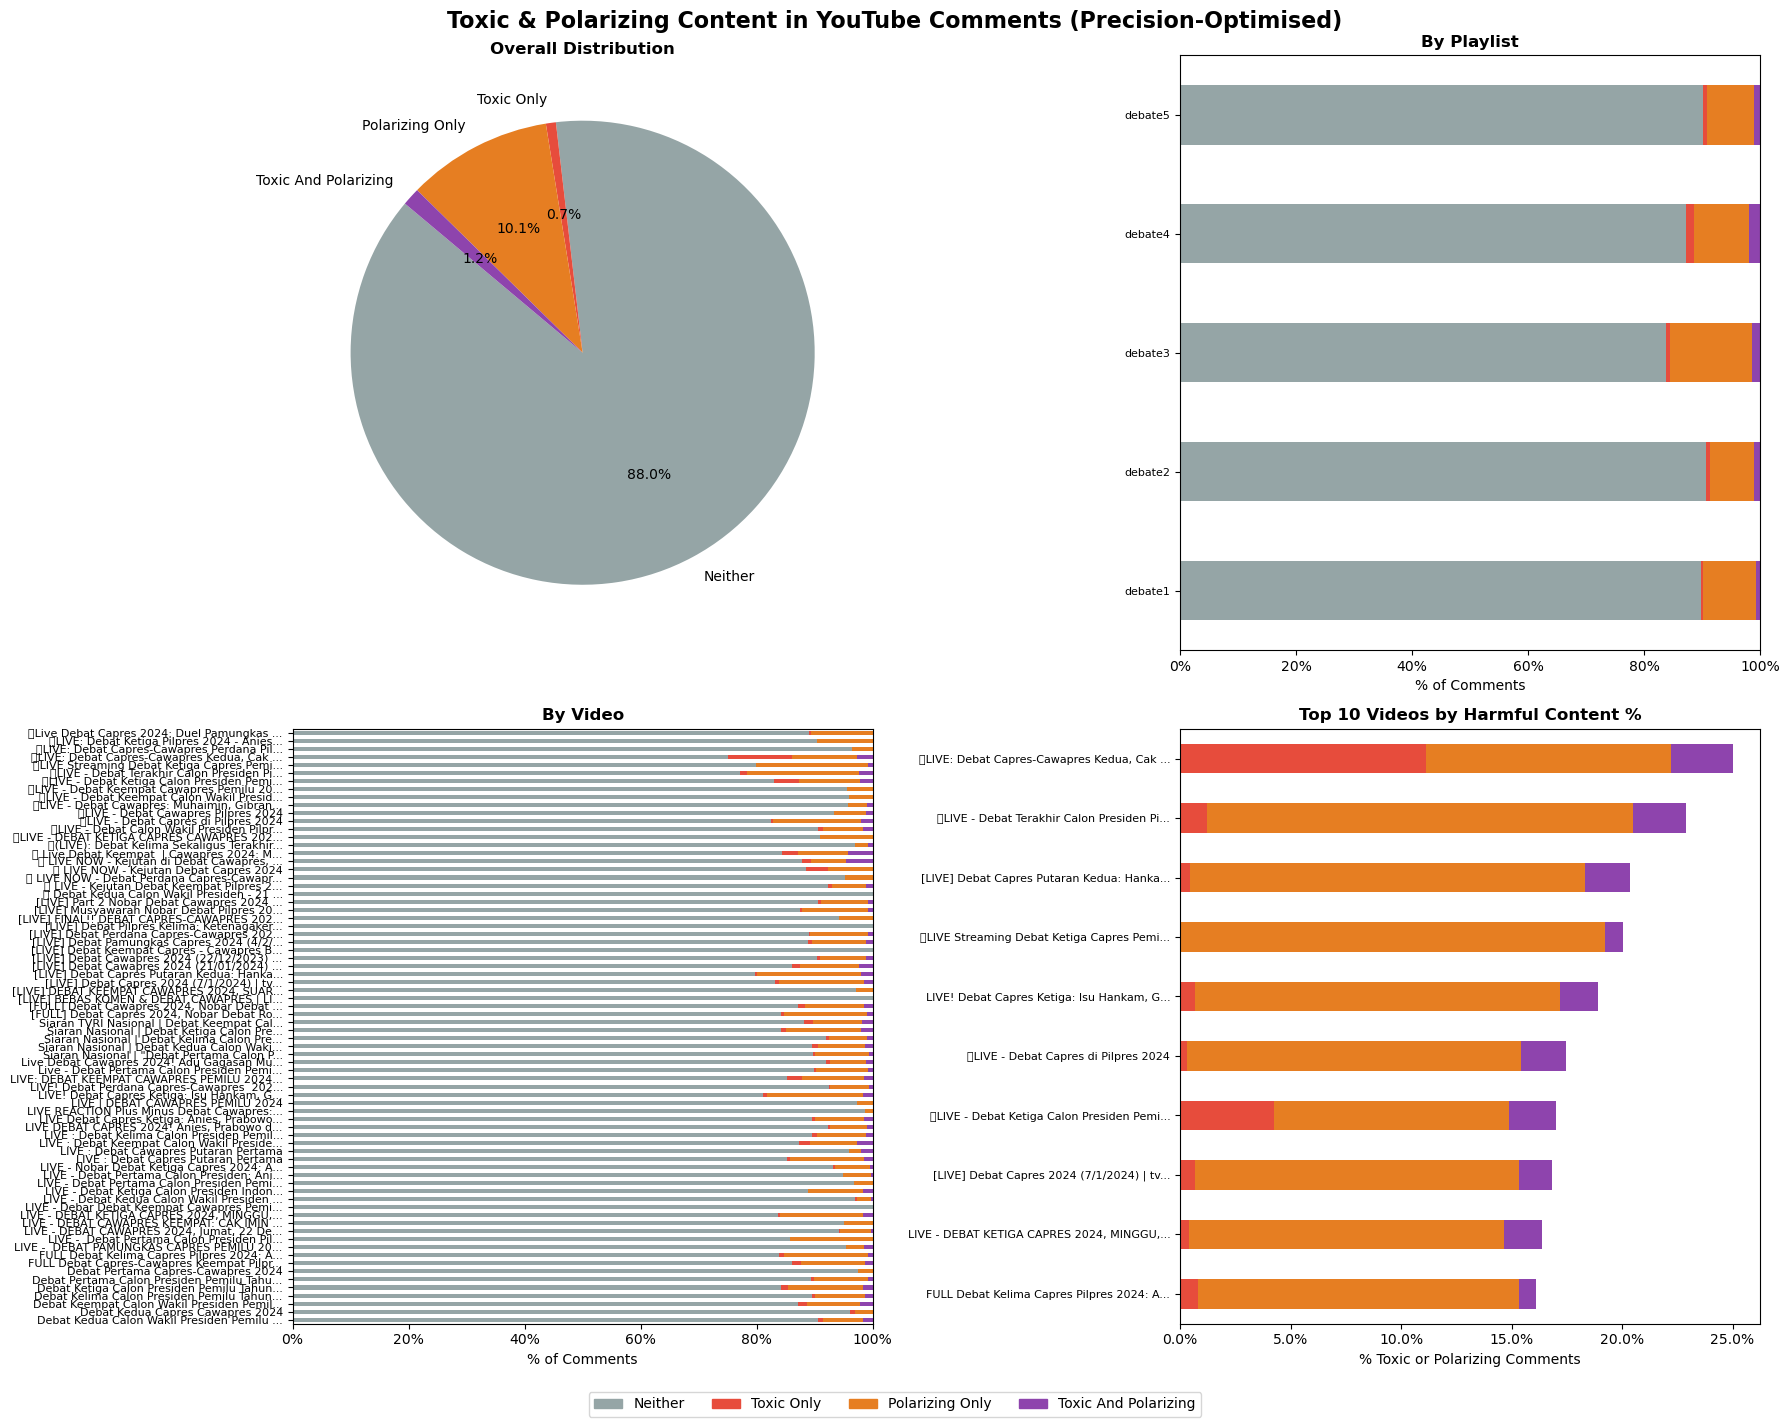

✓ Saved to content_analysis_precision.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Reads predictions_precision.csv
df = pd.read_csv('predictions_precision.csv')
LABEL_ORDER = ['neither', 'toxic only', 'polarizing only', 'toxic and polarizing']
COLOURS     = ['#95a5a6', '#e74c3c', '#e67e22', '#8e44ad']

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Toxic & Polarizing Content in YouTube Comments (Precision-Optimised)',
             fontsize=16, fontweight='bold')

def stacked_bar(ax, group_col, title):
    counts = (df.groupby([group_col, 'label']).size()
              .unstack(fill_value=0).reindex(columns=LABEL_ORDER, fill_value=0))
    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    pct.index = [t[:40]+'...' if len(t)>40 else t for t in pct.index]
    pct.plot(kind='barh', stacked=True, color=COLOURS, ax=ax, legend=False)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('% of Comments')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlim(0, 100)
    ax.tick_params(axis='y', labelsize=8)

counts = df['label'].value_counts().reindex(LABEL_ORDER, fill_value=0)
axes[0,0].pie(counts, labels=[l.title() for l in LABEL_ORDER],
              colors=COLOURS, autopct='%1.1f%%', startangle=140)
axes[0,0].set_title('Overall Distribution', fontweight='bold')

stacked_bar(axes[0,1], 'playlist_name', 'By Playlist')
stacked_bar(axes[1,0], 'video_title',   'By Video')

HARMFUL        = ['toxic only', 'polarizing only', 'toxic and polarizing']
HARMFUL_COLOURS = ['#e74c3c', '#e67e22', '#8e44ad']
harmful_total  = (df[df['label']!='neither'].groupby('video_title').size()
                  / df.groupby('video_title').size() * 100
                  ).dropna().sort_values().tail(10)
top10 = harmful_total.index.tolist()
counts_top10 = (df[df['video_title'].isin(top10)]
                .groupby(['video_title','label']).size()
                .unstack(fill_value=0).reindex(columns=HARMFUL, fill_value=0))
pct_top10 = counts_top10.div(df[df['video_title'].isin(top10)]
                              .groupby('video_title').size(), axis=0) * 100
pct_top10 = pct_top10.loc[top10]
pct_top10.index = [t[:40]+'...' if len(t)>40 else t for t in pct_top10.index]
pct_top10.plot(kind='barh', stacked=True, color=HARMFUL_COLOURS,
               ax=axes[1,1], legend=False)
axes[1,1].set_title('Top 10 Videos by Harmful Content %', fontweight='bold')
axes[1,1].set_xlabel('% Toxic or Polarizing Comments')
axes[1,1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1,1].tick_params(axis='y', labelsize=8)

handles = [plt.Rectangle((0,0),1,1, color=c) for c in COLOURS]
fig.legend(handles, [l.title() for l in LABEL_ORDER],
           loc='lower center', ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.03))
plt.tight_layout()
plt.savefig('content_analysis_precision.png', dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 Saved to content_analysis_precision.png')


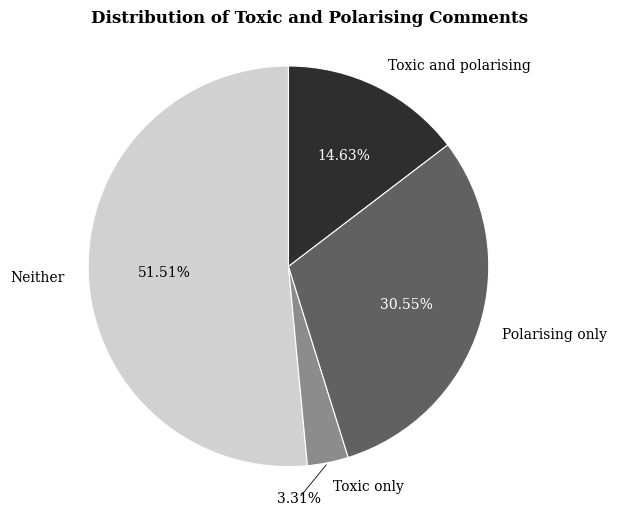

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# ── Academic style settings ────────────────────────────────────────────────
# Consistent with the dissertation's LaTeX tables and figures
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "text.color": "black",
    "axes.labelcolor": "black",
})

# ── Read data ───────────────────────────────────────────────────────────────
df = pd.read_csv("predictions_full.csv")

LABEL_ORDER = [
    "neither",
    "toxic only",
    "polarizing only",
    "toxic and polarizing"
]

# ── Greyscale palette ──────────────────────────────────────────────────────
COLOURS = [
    "0.82",   # Neither
    "0.55",   # Toxic only
    "0.38",   # Polarising only
    "0.18"    # Toxic and polarising
]

# ── Calculate counts ───────────────────────────────────────────────────────
counts = (
    df["label"]
    .value_counts()
    .reindex(LABEL_ORDER, fill_value=0)
)

# ── Figure ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.2, 5.2))
wedges, label_texts, percentage_texts = ax.pie(
    counts,
    labels=[
        "Neither",
        "Toxic only",
        "Polarising only",
        "Toxic and polarising"
    ],
    colors=COLOURS,
    autopct="%1.2f%%",
    startangle=90,
    counterclock=True,
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 0.8
    },
    textprops={
        "fontsize": 10
    },
    pctdistance=0.62,
    labeldistance=1.12
)

# ── Percentage label formatting ───────────────────────────────────────────
# Darker slices receive white percentage labels; lighter slices receive
# black labels. Small wedges (below SMALL_WEDGE_THRESHOLD degrees) have
# their percentage label pulled outside the pie with a leader line, since
# there is not enough room inside the wedge to display the text clearly.
SMALL_WEDGE_THRESHOLD = 15  # degrees
SMALL_WEDGE_X_OFFSET = -0.18  # shifts small-wedge label left, away from its category label
LEADER_INNER_RADIUS = 1.0     # start of leader line (closer to wedge edge)
LEADER_OUTER_RADIUS = 1.18    # end of leader line (shorter than before)

for i, (wedge, autotext) in enumerate(zip(wedges, percentage_texts)):
    angle_span = wedge.theta2 - wedge.theta1
    mid_angle = np.deg2rad((wedge.theta1 + wedge.theta2) / 2)

    if angle_span < SMALL_WEDGE_THRESHOLD:
        # Pull this label outside the pie with a shorter leader line
        x_inner = LEADER_INNER_RADIUS * np.cos(mid_angle)
        y_inner = LEADER_INNER_RADIUS * np.sin(mid_angle)
        x_outer = LEADER_OUTER_RADIUS * np.cos(mid_angle) + SMALL_WEDGE_X_OFFSET
        y_outer = LEADER_OUTER_RADIUS * np.sin(mid_angle)

        autotext.set_position((x_outer, y_outer))
        autotext.set_color("black")
        ax.annotate(
            "",
            xy=(x_inner, y_inner),
            xytext=(x_outer, y_outer),
            arrowprops=dict(arrowstyle="-", color="black", linewidth=0.6),
        )
    else:
        autotext.set_color("white" if i >= 2 else "black")

    autotext.set_fontsize(10)

# ── Category label formatting ──────────────────────────────────────────────
for label in label_texts:
    label.set_fontsize(10)
    label.set_color("black")

# ── Title ──────────────────────────────────────────────────────────────────
fig.suptitle(
    "Distribution of Toxic and Polarising Comments",
    fontsize=12,
    fontweight="bold",
    x=0.5,
    ha="center"
)

# Ensure the pie remains circular
ax.axis("equal")

# ── Layout and export ──────────────────────────────────────────────────────
plt.tight_layout()
plt.savefig(
    "content_distribution_pie.pdf",
    bbox_inches="tight"
)
plt.show()